In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/card_transdata.csv.zip')

In [ ]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [ ]:
df.isnull().sum()

,0
distance_from_home,0
distance_from_last_transaction,0
ratio_to_median_purchase_price,0
repeat_retailer,0
used_chip,0
used_pin_number,0
online_order,0
fraud,0


In [ ]:
df.nunique()

,0
distance_from_home,1000000
distance_from_last_transaction,1000000
ratio_to_median_purchase_price,1000000
repeat_retailer,2
used_chip,2
used_pin_number,2
online_order,2
fraud,2


In [ ]:
df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

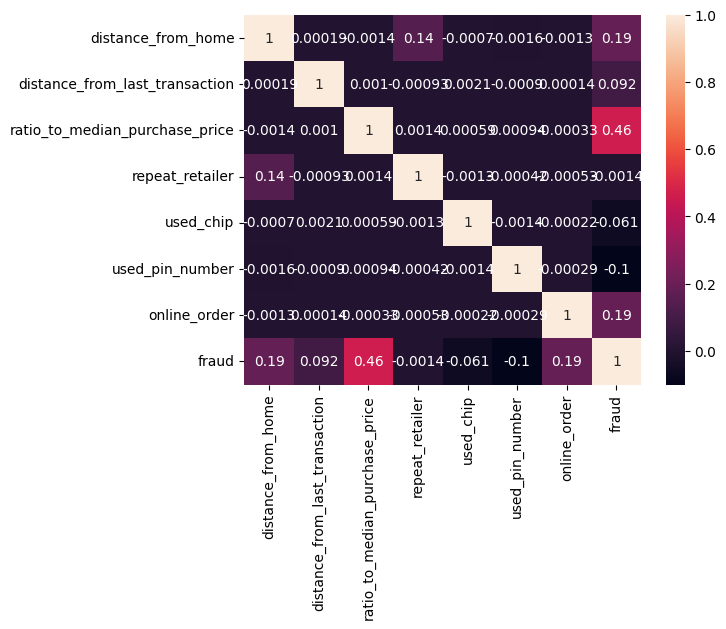

In [ ]:
sns.heatmap(df.corr(),annot = True)

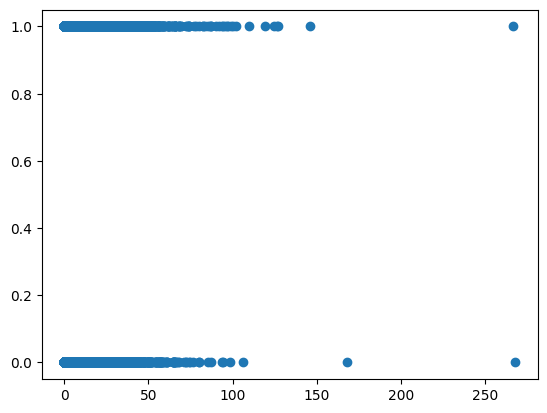

In [ ]:
plt.scatter(df['ratio_to_median_purchase_price'],df['fraud'])

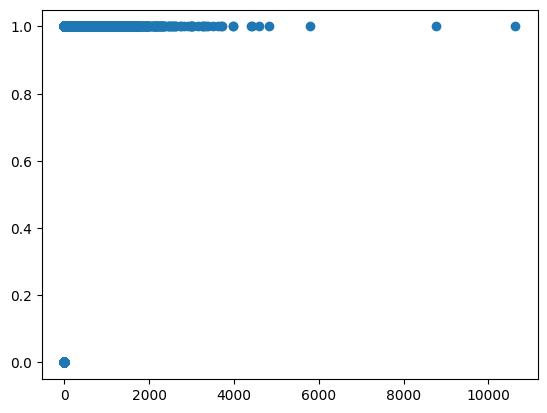

In [ ]:
plt.scatter(df['distance_from_home'],df['repeat_retailer'])

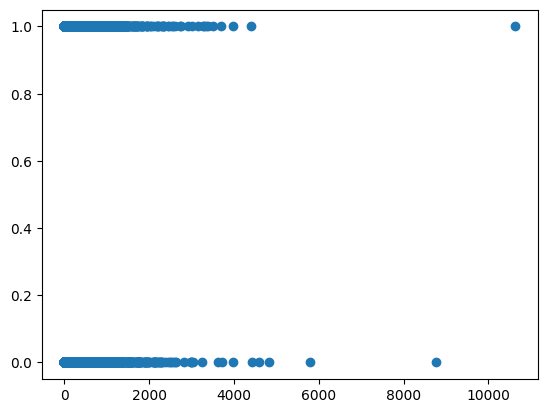

In [ ]:
plt.scatter(df['distance_from_home'],df['fraud'])

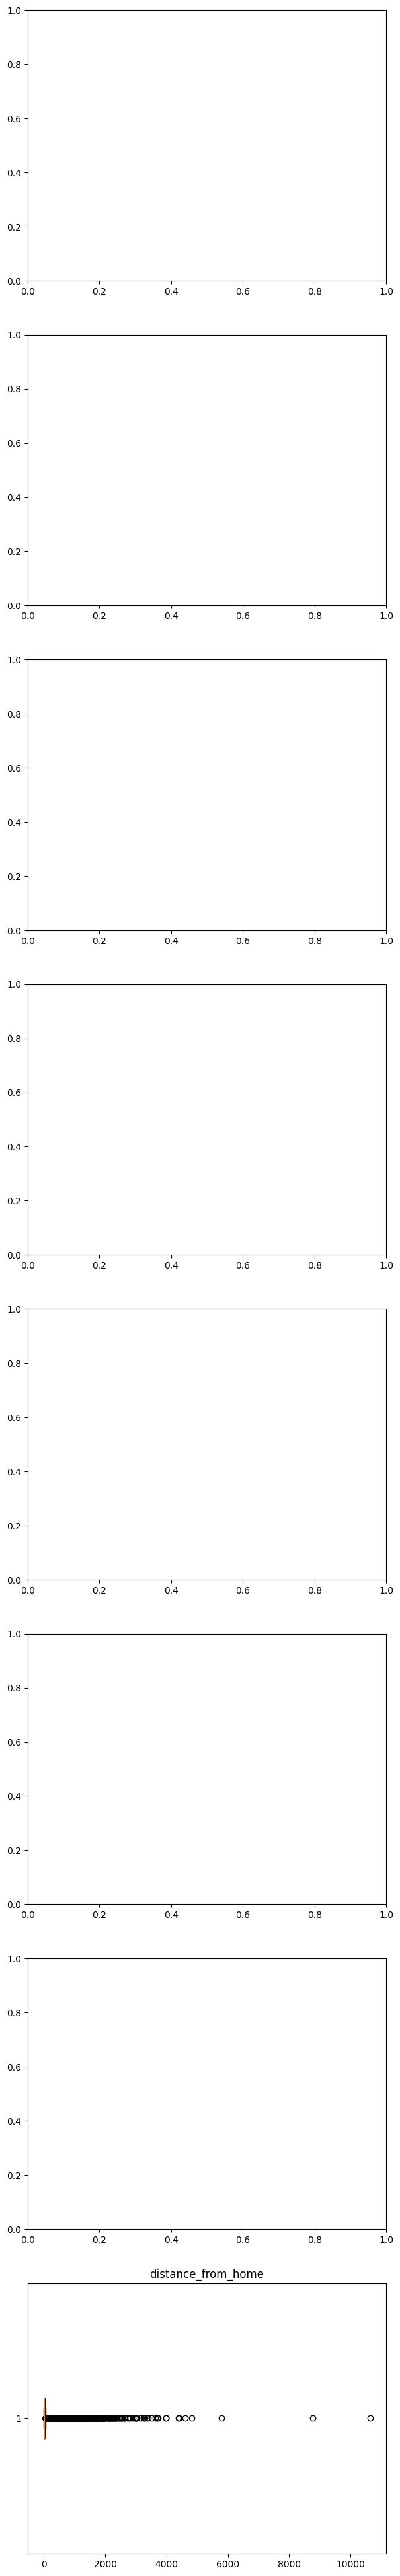

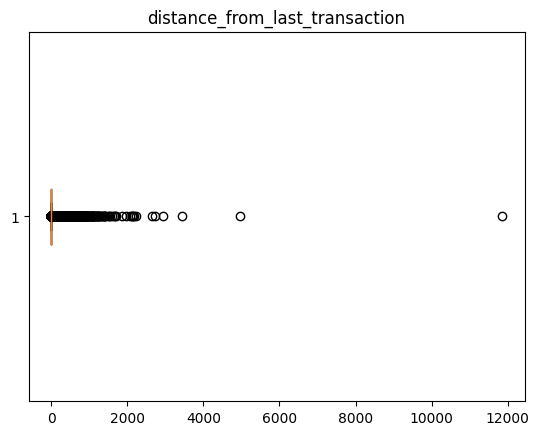

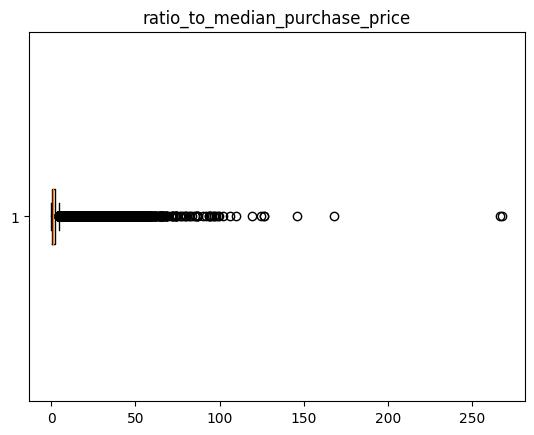

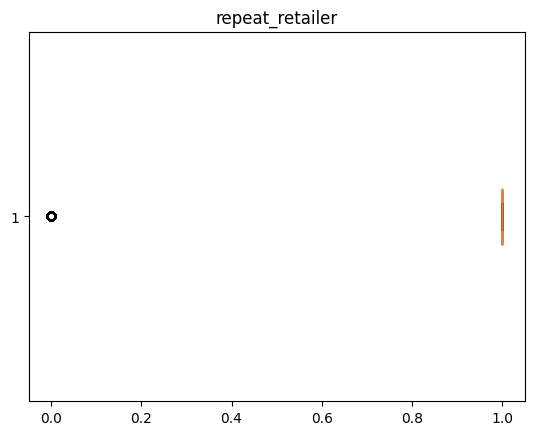

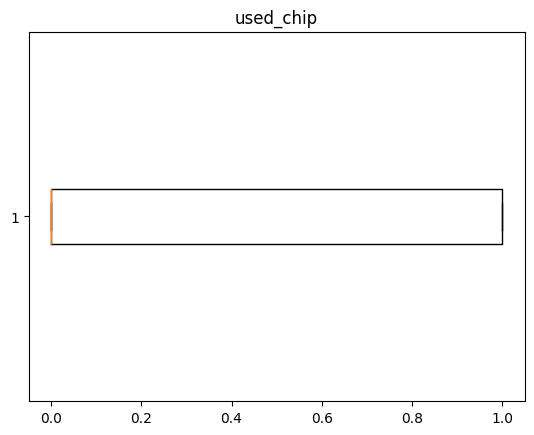

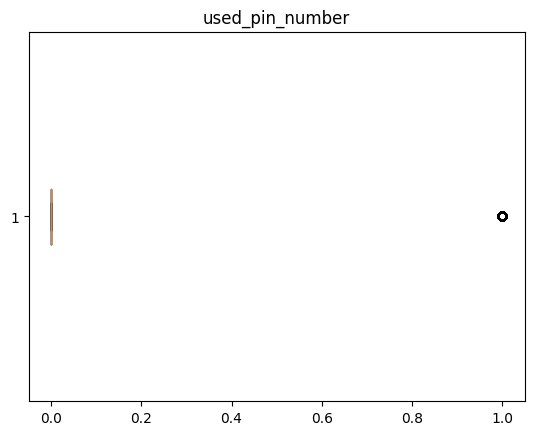

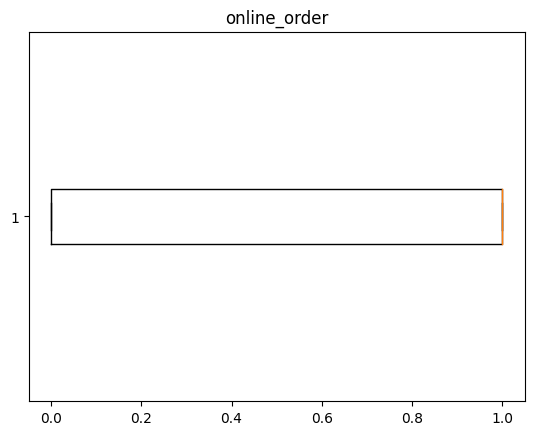

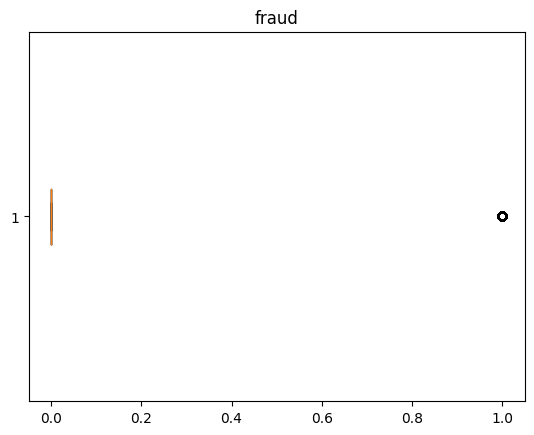

In [ ]:
fig,axs = plt.subplots(len(df.columns),1,figsize = (7,50))

for i,j in zip(df.columns,range(len(df.columns))):
  plt.title(i)
  axs[j] = plt.boxplot(df[i],vert = False)
  plt.show()

In [ ]:
mean = np.mean(df['distance_from_home'])
std = np.std(df['distance_from_home'])

lower = mean - 2 * std
upper = mean + 2 * std


mean1 = np.mean(df['distance_from_last_transaction'])
std1 = np.std(df['distance_from_last_transaction'])

lower1 = mean1 - 2 * std1
upper1 = mean1 + 2 * std1


mean2 = np.mean(df['ratio_to_median_purchase_price'])
std2 = np.std(df['ratio_to_median_purchase_price'])

lower2 = mean2 - 2 * std2
upper2 = mean2 + 2 * std2

df2 = df[(df['distance_from_home'] >= lower) & (df['distance_from_home'] <= upper) &
 (df['distance_from_last_transaction'] >= lower1) & (df['distance_from_last_transaction'] <= upper1) &
  (df['ratio_to_median_purchase_price'] >= lower2) & (df['ratio_to_median_purchase_price'] <= upper2)]

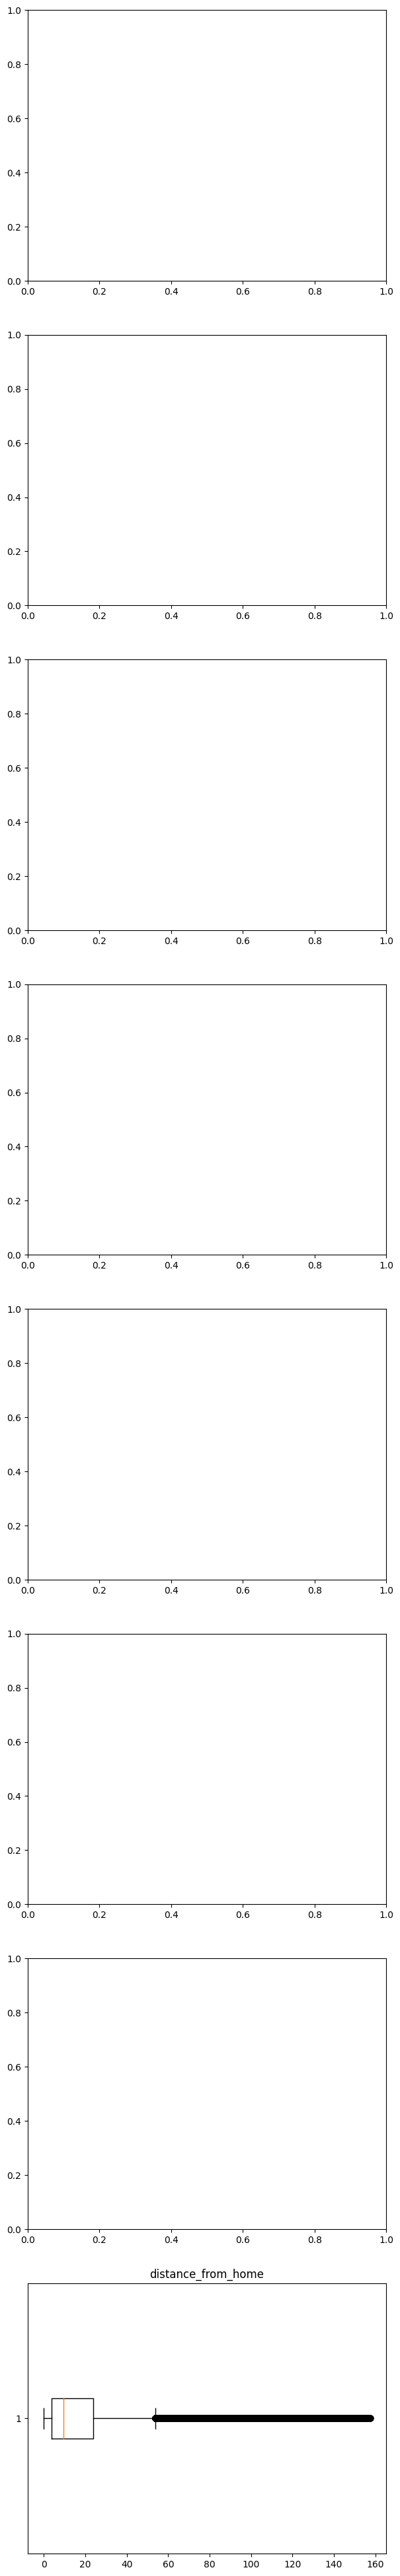

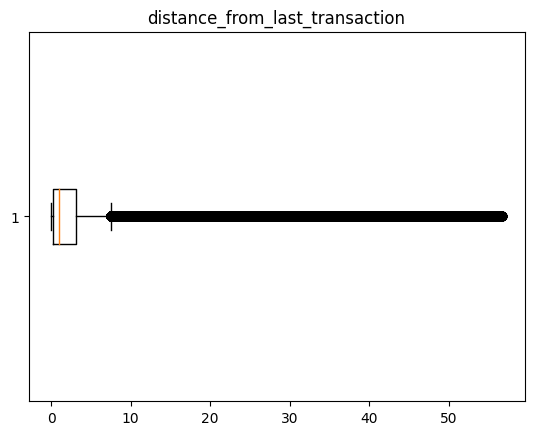

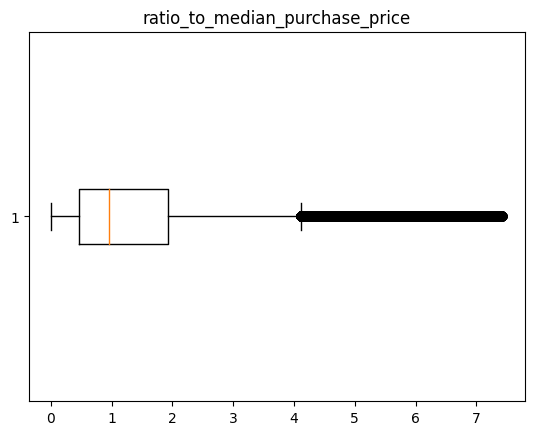

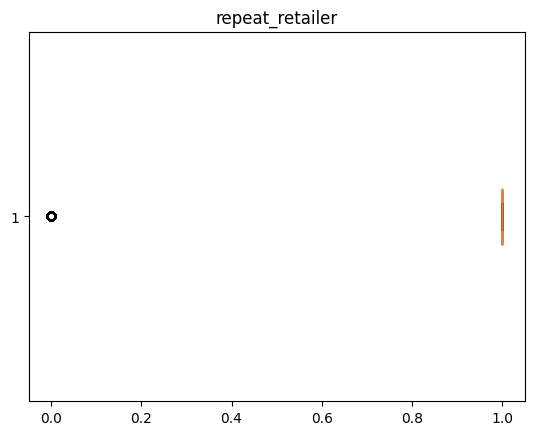

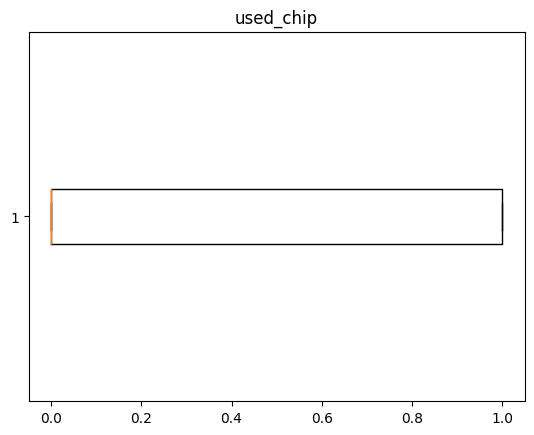

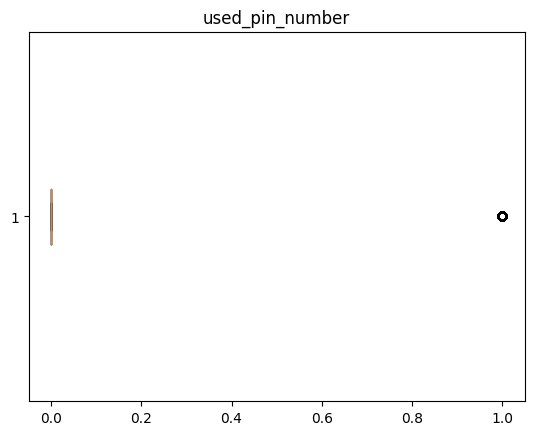

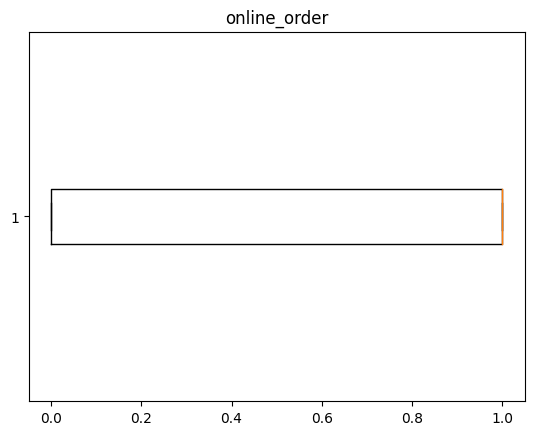

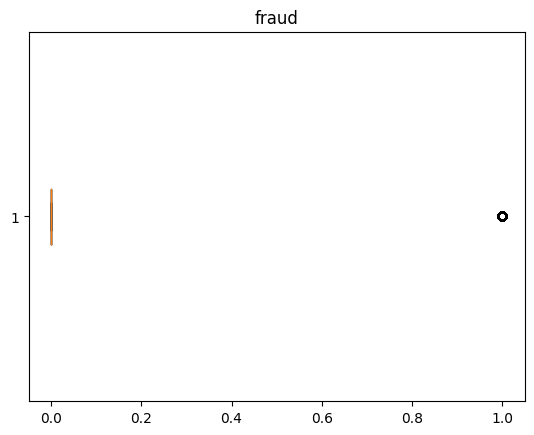

In [ ]:
fig,axs = plt.subplots(len(df2.columns),1,figsize = (7,50))

for i,j in zip(df2.columns,range(len(df2.columns))):
  plt.title(i)
  axs[j] = plt.boxplot(df2[i],vert = False)
  plt.show()

In [ ]:
df2.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df2.drop(columns = ['fraud']))

scaled_pd = pd.DataFrame(scaled,columns = df2.columns[ : -1])

In [ ]:
scaled_pd.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order
0,0.367677,0.005483,0.261701,1.0,1.0,0.0,0.0
1,0.068773,0.003094,0.173856,1.0,0.0,0.0,0.0
2,0.032314,0.014193,0.057059,1.0,0.0,0.0,1.0
3,0.014248,0.098727,0.048291,1.0,1.0,0.0,1.0
4,0.280722,0.009985,0.299015,1.0,1.0,0.0,1.0


In [ ]:
X = scaled_pd
y = df2.fraud

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99    176156
         1.0       0.83      0.71      0.77     10024

    accuracy                           0.98    186180
   macro avg       0.91      0.85      0.88    186180
weighted avg       0.98      0.98      0.98    186180

